In [3]:
import pandas as pd
data={
    'farm_id':['f001','f002','f003','f004','f005','f006','f007'],
    'crop':['wheat','rice','corn','wheat','rice','corn','wheat'],
    'yield_tons':[180,228,416,164,245,399,195],
    'rainfall_mm':[450,820,680,420,850,710,480],
   'fertilizer_kg':[120,150,200,110,160,195,125],
    'soil_ph':[6.5,5.8,6.2,6.7,5.9,6.1,6.4]
}
df=pd.DataFrame(data)
print(df)

df['yield_per_ha']=(df['yield_tons']/50).round(2)

print("\n====HIGH YIELD FARMS(>200 TONS)====")
high_yield=df[df['yield_tons']>200]
print(high_yield)

print('\n====RICE WITH HIGH RAINFALL(>800MM)====')
rice_high_rain=df[(df['crop']=='rice')&(df['rainfall_mm']>800)]
print(rice_high_rain)
print('\n====GRAIN CROPS(WHEAT&RICE)====')
grain_crops=df[df['crop'].isin(['wheat','rice'])]
print(grain_crops[['farm_id','crop','yield_tons']])
print('\n====OPTIMUM SOIL Ph(6.0 to 6.5)====')
optimal_ph=df[df['soil_ph'].between(6.0,6.5)]
print(optimal_ph[['farm_id','crop','soil_ph','yield_tons']])

print('\n===COMPLEX QUERY : GOOD CONDITION===')
min_rainfall=400
good_condition=df.query('rainfall_mm>@min_rainfall and fertilizer_kg>150')
print(good_condition[['farm_id','crop','rainfall_mm','fertilizer_kg']])

print('\n====FIRST 3 FARMS(iloc)====')
print(df.iloc[0:3])

print('\n====SPECIFIC COLUMN(loc)====')
print(df.loc[:,['farm_id','crop','yield_per_ha']])

print('\n====TOP PERFORMERS-SELECTED COLUMNS====')
top=df[df['yield_per_ha']>4.5][['farm_id','crop','yield_per_ha']]
print(top)


high=df[df['fertilizer_kg']>140]
print('\n\n',high)





  farm_id   crop  yield_tons  rainfall_mm  fertilizer_kg  soil_ph
0    f001  wheat         180          450            120      6.5
1    f002   rice         228          820            150      5.8
2    f003   corn         416          680            200      6.2
3    f004  wheat         164          420            110      6.7
4    f005   rice         245          850            160      5.9
5    f006   corn         399          710            195      6.1
6    f007  wheat         195          480            125      6.4

====HIGH YIELD FARMS(>200 TONS)====
  farm_id  crop  yield_tons  rainfall_mm  fertilizer_kg  soil_ph  yield_per_ha
1    f002  rice         228          820            150      5.8          4.56
2    f003  corn         416          680            200      6.2          8.32
4    f005  rice         245          850            160      5.9          4.90
5    f006  corn         399          710            195      6.1          7.98

====RICE WITH HIGH RAINFALL(>800MM)====

<Axes: >

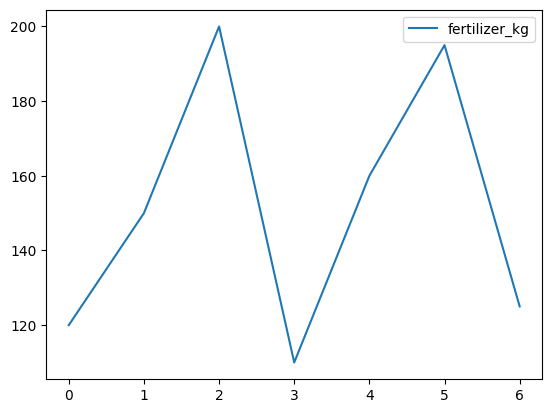

In [16]:
df[['fertilizer_kg','crop']].plot()

<Axes: >

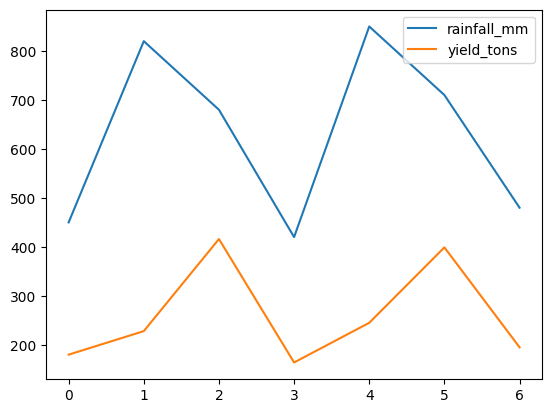

In [ ]:
df[['rainfall_mm','yield_tons']].plot()

<Axes: >

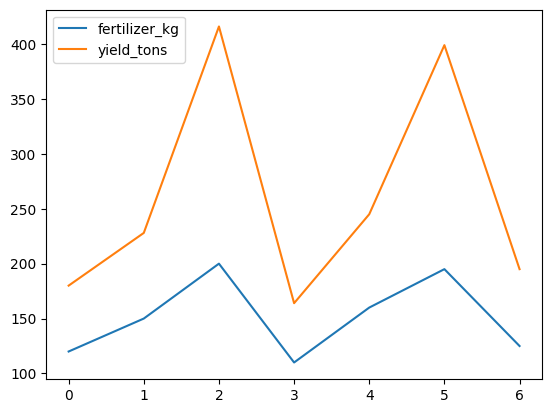

In [ ]:
df[['fertilizer_kg','yield_tons']].plot()

<Axes: >

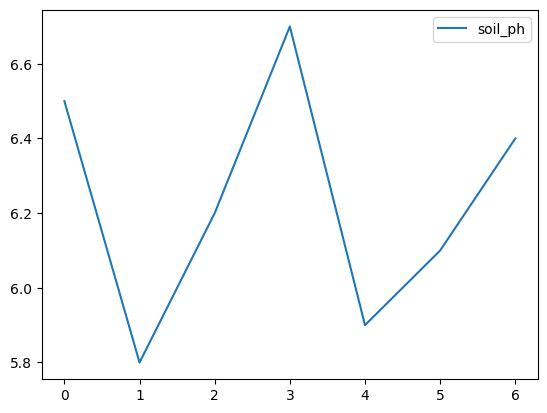

In [ ]:
df[['soil_ph']].plot()

<Axes: xlabel='fertilizer_kg'>

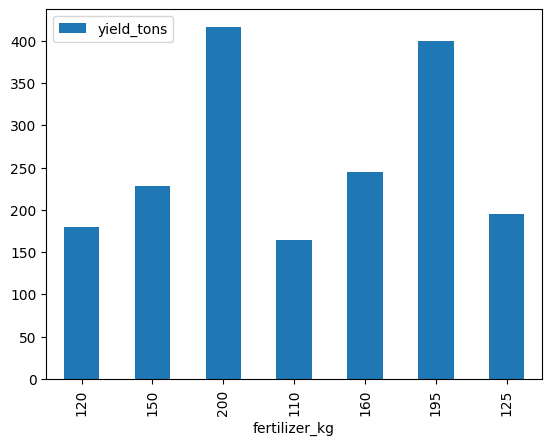

In [ ]:
df.plot(kind='bar',x='fertilizer_kg',y='yield_tons')

<Axes: xlabel='fertilizer_kg', ylabel='yield_tons'>

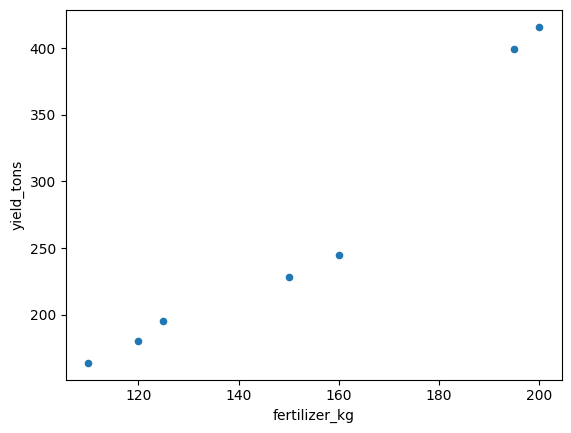

In [ ]:
df.plot(kind='scatter',x='fertilizer_kg',y='yield_tons')

<function matplotlib.pyplot.show(close=None, block=None)>

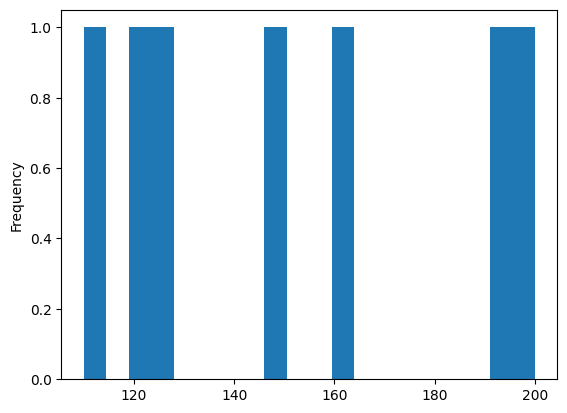

In [10]:
import matplotlib.pyplot as plt

df['fertilizer_kg'].plot(kind='hist',bins=20)
plt.show

<Axes: >

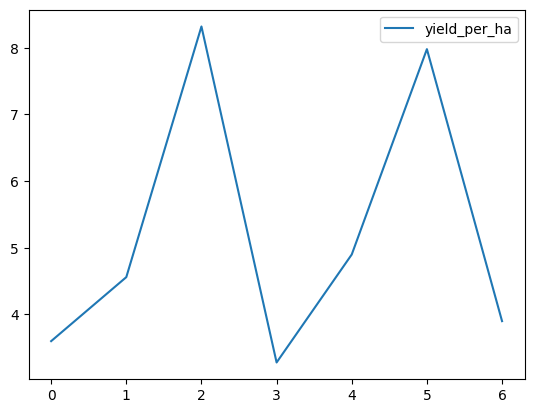

In [ ]:
df[['yield_per_ha']].plot()

<Axes: >

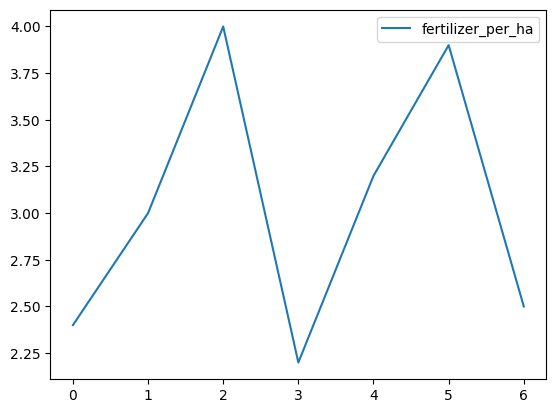

In [ ]:
df[['fertilizer_per_ha']].plot()

In [6]:
print(df.isna())

   farm_id   crop  yield_tons  rainfall_mm  fertilizer_kg  soil_ph  \
0    False  False       False        False          False    False   
1    False  False       False        False          False    False   
2    False  False       False        False          False    False   
3    False  False       False        False          False    False   
4    False  False       False        False          False    False   
5    False  False       False        False          False    False   
6    False  False       False        False          False    False   

   yield_per_ha  fertilizer_per_ha  
0         False              False  
1         False              False  
2         False              False  
3         False              False  
4         False              False  
5         False              False  
6         False              False  


In [28]:
import numpy as np
import pandas as pd

data= {
    'A': [1, 2, np.nan, 4, 5],
    'B': [np.nan, 2, 3, 4, 5],
    'C': [1, 2, 3, np.nan, 5],
    'D': [1, 2, 3, 4, np.nan]
}
df= pd.DataFrame(data)

print(df)

     A    B    C    D
0  1.0  NaN  1.0  1.0
1  2.0  2.0  2.0  2.0
2  NaN  3.0  3.0  3.0
3  4.0  4.0  NaN  4.0
4  5.0  5.0  5.0  NaN


In [30]:
df.isnull()

,A,B,C,D
0,False,True,False,False
1,False,False,False,False
2,True,False,False,False
3,False,False,True,False
4,False,False,False,True


In [34]:

df.isna().sum()

,0
A,1
B,1
C,1
D,1


In [35]:
df.dropna()

,A,B,C,D
1,2.0,2.0,2.0,2.0


In [36]:
df.dropna(axis=1)

""
0
1
2
3
4


In [37]:
df.dropna(how='all')

,A,B,C,D
0,1.0,NaN,1.0,1.0
1,2.0,2.0,2.0,2.0
2,NaN,3.0,3.0,3.0
3,4.0,4.0,NaN,4.0
4,5.0,5.0,5.0,NaN


In [46]:
df.drop(columns=['A']).dropna(thresh=3)


,B,C,D
1,2.0,2.0,2.0
2,3.0,3.0,3.0


In [49]:
df.fillna(3)

,A,B,C,D
0,1.0,3.0,1.0,1.0
1,2.0,2.0,2.0,2.0
2,3.0,3.0,3.0,3.0
3,4.0,4.0,3.0,4.0
4,5.0,5.0,5.0,3.0


In [52]:
df['A'].fillna(df['A'].mean())

,A
0,1.0
1,2.0
2,3.0
3,4.0
4,5.0


In [53]:
df.fillna({'A':0,'B':3,'c':'unknown'})

,A,B,C,D
0,1.0,3.0,1.0,1.0
1,2.0,2.0,2.0,2.0
2,0.0,3.0,3.0,3.0
3,4.0,4.0,NaN,4.0
4,5.0,5.0,5.0,NaN
